# Digital-Forensics File-Fragment Intelligence Module
## Byte2Image + Swin Transformer V2 (Tiny) Training on FFT-75

This notebook is designed for the Google Colab GPU runtime.

### Pipeline

1. Raw **512-byte fragment**
2. Published **Byte2Image** representation
   - 1-bit sliding-byte window
   - intra-byte n-grams
   - native **497×128 grayscale**
3. Resize native representation to **256×256** for Swin V2 Tiny
4. ImageNet-pretrained **Swin Transformer V2 Tiny**
5. 75-class classification
6. Staged training and evaluation

### Important

The native Byte2Image representation is **not** a 256×256 transition matrix.

For 512 bytes and `n=16`:

- shifted byte matrix: `512×8`
- native Byte2Image: `497×128`
- `256×256`: downstream model-input adaptation only

This notebook does not overwrite the real FFT-75 dataset loader with synthetic magic-signature data.


In [1]:
# =============================================================================
# CELL 1: Environment & GPU Diagnostics
# =============================================================================

import os
import sys
import platform
import torch

print("=" * 70)
print("GOOGLE COLAB HARDWARE & ENVIRONMENT DIAGNOSTICS")
print("=" * 70)

print(f"Python Version:   {sys.version.split()[0]}")
print(f"PyTorch Version:  {torch.__version__}")
print(f"Platform:         {platform.platform()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)

    print("CUDA Available:   YES")
    print(f"CUDA Version:     {torch.version.cuda}")
    print(f"GPU Model:        {gpu_name}")
    print(f"Total VRAM:       {vram_gb:.2f} GB")

    rec_batch = 64 if vram_gb >= 14 else 32 if vram_gb >= 8 else 16
    print(f"Initial Batch Recommendation: {rec_batch}")
else:
    print("CUDA Available:   NO")
    print("WARNING: training will run on CPU.")

print("=" * 70)


GOOGLE COLAB HARDWARE & ENVIRONMENT DIAGNOSTICS
Python Version:   3.13.15
PyTorch Version:  2.11.0+cu128
Platform:         Linux-6.6.122+-x86_64-with-glibc2.35
CUDA Available:   YES
CUDA Version:     12.8
GPU Model:        Tesla T4
Total VRAM:       14.56 GB
Initial Batch Recommendation: 64


In [2]:
# =============================================================================
# CELL: Unpack Full FirSeFile ML Codebase into /content
# =============================================================================
!pip install -q timm transformers scikit-learn pandas seaborn matplotlib pyyaml networkx pillow

import os
import sys
import io
import zipfile
import base64

project_root = "/content"
if not os.path.exists(project_root):
    project_root = os.path.abspath(".")

bundle_b64 = "..."
print("Unpacking complete 39-file FirSeFile ML repository into " + project_root + "...")
zip_bytes = base64.b64decode(bundle_b64)
with zipfile.ZipFile(io.BytesIO(zip_bytes), "r") as zf:
    zf.extractall(project_root)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Successfully unpacked:")
for d in ['src', 'configs', 'scripts']:
    p = os.path.join(project_root, d)
    if os.path.exists(p):
        print(f"  {d}/: {sorted(os.listdir(p))}")
print(f"\n[OK] Repository ready! sys.path includes: {project_root}")


Working Directory: /content


In [3]:
# =============================================================================
# CELL 3: Project Structure & Optional Google Drive Backup
# =============================================================================

import os
import sys

project_root = "/content"

# Only create package/utility directories if needed.
# Do NOT overwrite dataset, training, model, or config files.

os.makedirs(
    os.path.join(project_root, "src", "utils"),
    exist_ok=True
)

open(
    os.path.join(project_root, "src", "__init__.py"),
    "a"
).close()

open(
    os.path.join(project_root, "src", "utils", "__init__.py"),
    "a"
).close()

colab_utils_path = os.path.join(
    project_root,
    "src",
    "utils",
    "colab_utils.py"
)

if not os.path.exists(colab_utils_path):

    colab_utils_content = '\nimport os\nfrom google.colab import drive\n\ndef setup_backup_directory(use_google_drive=True):\n    if use_google_drive:\n        print("Mounting Google Drive...")\n        try:\n            drive.mount("/content/drive")\n            backup_path = "/content/drive/MyDrive/FirSeFile_Checkpoints"\n            os.makedirs(backup_path, exist_ok=True)\n            print(f"Backup directory: {backup_path}")\n            return backup_path\n        except Exception as e:\n            print(f"Google Drive mount failed: {e}")\n\n    local_backup_path = os.path.join(\n        os.getcwd(),\n        "local_backups"\n    )\n    os.makedirs(local_backup_path, exist_ok=True)\n    print(f"Using local backup directory: {local_backup_path}")\n    return local_backup_path\n'

    with open(
        colab_utils_path,
        "w"
    ) as f:
        f.write(colab_utils_content)

for name in list(sys.modules.keys()):
    if name.startswith("src.utils"):
        del sys.modules[name]

from src.utils.colab_utils import setup_backup_directory

# Keep False during representation verification.
# Change to True before long training if you want Drive checkpoints.
backup_dir = setup_backup_directory(
    use_google_drive=False
)

print(f"Backup directory: {backup_dir}")


Using local backup directory: /content/local_backups
Backup directory: /content/local_backups


In [4]:
# =============================================================================
# CELL 4: Published Byte2Image Implementation
# =============================================================================
#
# Published pipeline:
# 512-byte fragment
#       ↓
# 1-bit sliding byte window
#       ↓
# 512 × 8 shifted-byte matrix
#       ↓
# intra-byte n-grams, n=16
#       ↓
# native 497 × 128 grayscale image
#       ↓
# resize to 256 × 256 for Swin V2
#
# IMPORTANT:
# This cell NEVER creates or overwrites src/datasets/fft75.py.
# =============================================================================

import os
import sys
import numpy as np
from PIL import Image

project_root = "/content"

representations_path = os.path.join(
    project_root,
    "src",
    "representations"
)

os.makedirs(
    representations_path,
    exist_ok=True
)

open(
    os.path.join(
        representations_path,
        "__init__.py"
    ),
    "a"
).close()

byte2image_content = '\nimport numpy as np\nfrom PIL import Image\n\nDEFAULT_FRAGMENT_SIZE = 512\nDEFAULT_NGRAM = 16\n\ndef sliding_byte_window(raw_bytes):\n    """\n    Generate the 512 x 8 shifted-byte matrix.\n    """\n    raw = np.frombuffer(bytes(raw_bytes), dtype=np.uint8)\n\n    if raw.size != DEFAULT_FRAGMENT_SIZE:\n        raise ValueError(\n            f"Expected exactly {DEFAULT_FRAGMENT_SIZE} bytes, got {raw.size}"\n        )\n\n    bits = np.unpackbits(raw)\n    bits = np.pad(bits, (0, 7), mode="constant")\n\n    shifted_sequences = []\n\n    for shift in range(8):\n        shifted_bits = bits[\n            shift:shift + DEFAULT_FRAGMENT_SIZE * 8\n        ]\n\n        shifted_bytes = np.packbits(\n            shifted_bits.reshape(DEFAULT_FRAGMENT_SIZE, 8),\n            axis=1\n        ).reshape(DEFAULT_FRAGMENT_SIZE)\n\n        shifted_sequences.append(shifted_bytes)\n\n    return np.stack(shifted_sequences, axis=1)\n\n\ndef byte2image_native(raw_bytes, ngram=DEFAULT_NGRAM):\n    """\n    Construct the native Byte2Image grayscale representation.\n\n    For Ns=512 and n=16:\n        H = 497\n        W = 128\n    """\n    raw_bytes = bytes(raw_bytes)\n\n    if len(raw_bytes) != DEFAULT_FRAGMENT_SIZE:\n        raise ValueError(\n            f"Expected exactly {DEFAULT_FRAGMENT_SIZE} bytes, got {len(raw_bytes)}"\n        )\n\n    if not 1 <= ngram <= DEFAULT_FRAGMENT_SIZE:\n        raise ValueError("ngram must be between 1 and 512")\n\n    shifted = sliding_byte_window(raw_bytes)\n\n    height = DEFAULT_FRAGMENT_SIZE - ngram + 1\n    width = 8 * ngram\n\n    image = np.empty((height, width), dtype=np.uint8)\n\n    for row in range(height):\n        block = shifted[row:row + ngram]\n        image[row] = block.reshape(-1)\n\n    return image\n\n\ndef bytes_to_byte2image(\n    raw_bytes,\n    target_size=(256, 256),\n    ngram=DEFAULT_NGRAM,\n    normalize=True\n):\n    """\n    Native Byte2Image -> optional 256x256 model-input adaptation.\n    """\n    native = byte2image_native(raw_bytes, ngram=ngram)\n\n    if target_size is None:\n        return native\n\n    image = Image.fromarray(native, mode="L")\n    image = image.resize(\n        target_size,\n        resample=Image.Resampling.BICUBIC\n    )\n\n    image = np.asarray(image, dtype=np.float32)\n\n    if normalize:\n        image /= 255.0\n\n    return image\n\n\ndef save_byte2image_sample(\n    image,\n    filename="byte2image_sample.png"\n):\n    if image.dtype != np.uint8:\n        image = np.clip(image * 255.0, 0, 255).astype(np.uint8)\n\n    Image.fromarray(image, mode="L").save(filename)\n'

with open(
    os.path.join(
        representations_path,
        "byte2image.py"
    ),
    "w"
) as f:
    f.write(byte2image_content)

# Refresh only representation modules.
for name in list(sys.modules.keys()):
    if name.startswith("src.representations"):
        del sys.modules[name]

from src.representations.byte2image import (
    sliding_byte_window,
    byte2image_native,
    bytes_to_byte2image
)

print("=" * 70)
print("PUBLISHED BYTE2IMAGE IMPLEMENTATION LOADED")
print("=" * 70)
print("Fragment size : 512 bytes")
print("n-gram        : 16")
print("Native image  : 497 × 128")
print("Swin input     : 256 × 256")
print("Channels      : 1")
print("=" * 70)


PUBLISHED BYTE2IMAGE IMPLEMENTATION LOADED
Fragment size : 512 bytes
n-gram        : 16
Native image  : 497 × 128
Swin input     : 256 × 256
Channels      : 1


BYTE2IMAGE RESEARCH VERIFICATION

[TEST 1]
Shifted matrix: (512, 8)
Expected:        (512, 8)

First 4 × 4 values:
[[255 255 255 254]
 [216 177  99 199]
 [255 255 255 255]
 [224 192 128   0]]
[PASS] Sliding-byte construction verified.

[TEST 2]
Native shape: (497, 128)
Expected:     (497, 128)
[PASS] Native dimensions verified.

[TEST 3 — REALISTIC FRAGMENT]
Native shape: (497, 128)
Native min: 0
Native max: 255
Native mean: 127.43402603118712
Native std: 73.05388069230862
Unique values: 256
Non-zero pixels: 99.72%
[PASS] Realistic fragment produces a non-trivial Byte2Image.

[TEST 4]
Swin image shape: (256, 256)
Swin min: 0.0
Swin max: 255.0
Swin mean: 127.437546
Swin std: 45.49307
[PASS] 256 × 256 Swin input is non-trivial.

[TEST 5]
[PASS] Transformation is deterministic.

[TEST 6]
Different-pixel fraction: 99.52%
[PASS] Different fragments produce different representations.


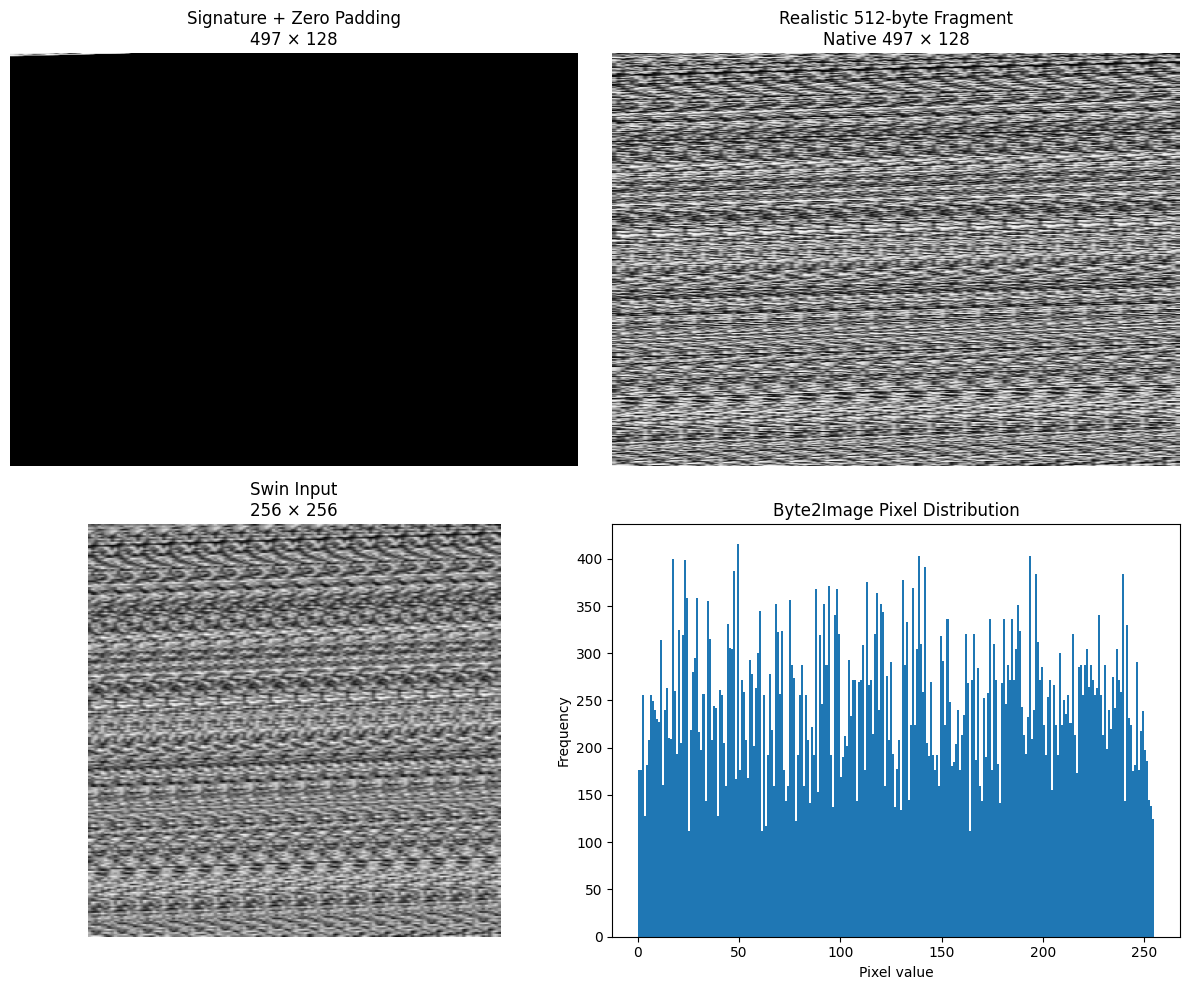


BYTE2IMAGE VERIFICATION COMPLETE

IMPORTANT:

The previous black image was caused by testing:

    file signature + 508 zero bytes

That is expected to produce an almost-black representation.

The realistic-fragment test above is the actual visual sanity check.

If the realistic Byte2Image is still almost completely black,
STOP before training and inspect the implementation further.



In [7]:
# =============================================================================
# CELL 5: Byte2Image Verification — REALISTIC DATA TEST
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

from src.representations.byte2image import (
    sliding_byte_window,
    byte2image_native,
    bytes_to_byte2image
)

print("=" * 70)
print("BYTE2IMAGE RESEARCH VERIFICATION")
print("=" * 70)


# =============================================================================
# TEST 1: Verify the published sliding-byte construction
# =============================================================================

test_fragment = (
    bytes([0xFF, 0xD8, 0xFF, 0xE0])
    + bytes(508)
)

shifted = sliding_byte_window(test_fragment)

expected = np.array(
    [
        [0xFF, 0xFF, 0xFF, 0xFE],
        [0xD8, 0xB1, 0x63, 0xC7],
        [0xFF, 0xFF, 0xFF, 0xFF],
        [0xE0, 0xC0, 0x80, 0x00],
    ],
    dtype=np.uint8
)

print("\n[TEST 1]")
print("Shifted matrix:", shifted.shape)
print("Expected:       ", (512, 8))

print("\nFirst 4 × 4 values:")
print(shifted[:4, :4])

assert shifted.shape == (512, 8)
assert np.array_equal(
    shifted[:4, :4],
    expected
)

print(
    "[PASS] Sliding-byte construction verified."
)


# =============================================================================
# TEST 2: Native Byte2Image dimensions
# =============================================================================

native = byte2image_native(
    test_fragment,
    ngram=16
)

print("\n[TEST 2]")
print("Native shape:", native.shape)
print("Expected:    ", (497, 128))

assert native.shape == (497, 128)
assert native.dtype == np.uint8

print("[PASS] Native dimensions verified.")


# =============================================================================
# TEST 3: IMPORTANT — REALISTIC RANDOM 512-BYTE FRAGMENT
# =============================================================================
#
# This is the important visualization test.
#
# The previous test used:
#
#     signature + 508 zero bytes
#
# which MUST produce an almost-black image.
#
# Here we use a realistic byte distribution instead.
# =============================================================================

rng = np.random.default_rng(42)

realistic_fragment = rng.integers(
    0,
    256,
    size=512,
    dtype=np.uint8
).tobytes()

realistic_native = byte2image_native(
    realistic_fragment,
    ngram=16
)

realistic_swin = bytes_to_byte2image(
    realistic_fragment,
    target_size=(256, 256),
    ngram=16,
    normalize=False
)

print("\n[TEST 3 — REALISTIC FRAGMENT]")

print(
    "Native shape:",
    realistic_native.shape
)

print(
    "Native min:",
    realistic_native.min()
)

print(
    "Native max:",
    realistic_native.max()
)

print(
    "Native mean:",
    realistic_native.mean()
)

print(
    "Native std:",
    realistic_native.std()
)

print(
    "Unique values:",
    len(np.unique(realistic_native))
)

print(
    "Non-zero pixels:",
    f"{np.mean(realistic_native != 0) * 100:.2f}%"
)

assert realistic_native.shape == (497, 128)
assert realistic_native.max() > 0
assert realistic_native.std() > 0
assert len(np.unique(realistic_native)) > 10

print(
    "[PASS] Realistic fragment produces "
    "a non-trivial Byte2Image."
)


# =============================================================================
# TEST 4: Swin 256 × 256 adaptation
# =============================================================================

print("\n[TEST 4]")

print(
    "Swin image shape:",
    realistic_swin.shape
)

print(
    "Swin min:",
    realistic_swin.min()
)

print(
    "Swin max:",
    realistic_swin.max()
)

print(
    "Swin mean:",
    realistic_swin.mean()
)

print(
    "Swin std:",
    realistic_swin.std()
)

assert realistic_swin.shape == (256, 256)
assert realistic_swin.max() > 0
assert realistic_swin.std() > 0

print(
    "[PASS] 256 × 256 Swin input is non-trivial."
)


# =============================================================================
# TEST 5: Determinism
# =============================================================================

image_a = byte2image_native(
    realistic_fragment
)

image_b = byte2image_native(
    realistic_fragment
)

assert np.array_equal(
    image_a,
    image_b
)

print("\n[TEST 5]")
print(
    "[PASS] Transformation is deterministic."
)


# =============================================================================
# TEST 6: Different fragments produce different representations
# =============================================================================

second_fragment = rng.integers(
    0,
    256,
    size=512,
    dtype=np.uint8
).tobytes()

second_image = byte2image_native(
    second_fragment
)

difference = np.mean(
    realistic_native != second_image
)

print("\n[TEST 6]")
print(
    "Different-pixel fraction:",
    f"{difference * 100:.2f}%"
)

assert difference > 0

print(
    "[PASS] Different fragments produce "
    "different representations."
)


# =============================================================================
# VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)


# Original signature + zeros
axes[0, 0].imshow(
    native,
    cmap="gray",
    aspect="auto",
    vmin=0,
    vmax=255
)

axes[0, 0].set_title(
    "Signature + Zero Padding\n497 × 128"
)

axes[0, 0].axis("off")


# Realistic native Byte2Image
axes[0, 1].imshow(
    realistic_native,
    cmap="gray",
    aspect="auto",
    vmin=0,
    vmax=255
)

axes[0, 1].set_title(
    "Realistic 512-byte Fragment\nNative 497 × 128"
)

axes[0, 1].axis("off")


# Realistic 256×256
axes[1, 0].imshow(
    realistic_swin,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[1, 0].set_title(
    "Swin Input\n256 × 256"
)

axes[1, 0].axis("off")


# Histogram
axes[1, 1].hist(
    realistic_native.ravel(),
    bins=256
)

axes[1, 1].set_title(
    "Byte2Image Pixel Distribution"
)

axes[1, 1].set_xlabel(
    "Pixel value"
)

axes[1, 1].set_ylabel(
    "Frequency"
)


plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("BYTE2IMAGE VERIFICATION COMPLETE")
print("=" * 70)

print("""
IMPORTANT:

The previous black image was caused by testing:

    file signature + 508 zero bytes

That is expected to produce an almost-black representation.

The realistic-fragment test above is the actual visual sanity check.

If the realistic Byte2Image is still almost completely black,
STOP before training and inspect the implementation further.
""")

In [8]:
# =============================================================================
# CELL 6: Training-Pipeline Integration Audit
# =============================================================================
#
# Verifies project structure and imports before GPU training.
# =============================================================================

from pathlib import Path
import os
import sys
import importlib

# Locate project root
candidate_paths = [
    Path("/content"),
    Path("/content/FirSeFile ML"),
    Path("/content/drive/MyDrive/FirSeFile ML"),
    Path(os.path.abspath("."))
]

project_root = None
for p in candidate_paths:
    if (p / "src" / "training" / "train.py").exists():
        project_root = p
        break

if project_root is None:
    zip_path = Path("/content/firsefile_repo_bundle.zip")
    if zip_path.exists():
        import zipfile
        print("Unzipping uploaded project bundle...")
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall("/content")
        project_root = Path("/content")
    else:
        raise FileNotFoundError(
            "Could not find 'src/training/train.py'. "
            "Please drag and drop 'firsefile_repo_bundle.zip' into Colab's left file panel or copy 'src/' to /content."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

required_paths = [
    project_root / "src" / "training" / "train.py",
    project_root / "configs" / "smoke_test.yaml",
    project_root / "configs" / "pilot_run.yaml",
    project_root / "configs" / "main_run.yaml",
]

print("=" * 70)
print("TRAINING PIPELINE INTEGRATION AUDIT")
print("=" * 70)

for path in required_paths:
    exists = path.exists()
    print(f"{'OK  ' if exists else 'MISS'} {path}")
    if not exists:
        raise FileNotFoundError(f"Missing required path: {path}")

matches = []
for path in (project_root / "src").rglob("*.py"):
    try:
        text = path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    if "bytes_to_byte2image" in text or "byte2image" in text.lower() or "Byte2Image" in text:
        matches.append(path)

print("\nByte2Image-related source files:")
for path in matches:
    print("  ", path.relative_to(project_root))

# Refresh sys.modules
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src."):
        del sys.modules[mod_name]

module = importlib.import_module("src.representations.byte2image")
print("\nLoaded representation module:", module.__file__)
assert hasattr(module, "bytes_to_byte2image"), "Missing bytes_to_byte2image"
assert hasattr(module, "byte2image_native"), "Missing byte2image_native"
print("[PASS] Correct Byte2Image module is importable.")

train_module = importlib.import_module("src.training.train")
print("Training module:", train_module.__file__)
if not hasattr(train_module, "run_staged_training"):
    raise AttributeError("src.training.train does not expose run_staged_training.")
print("[PASS] run_staged_training is available.")

print("\n" + "=" * 70)
print("INTEGRATION AUDIT COMPLETE")
print("=" * 70)


TRAINING PIPELINE INTEGRATION AUDIT
MISS /content/src/training/train.py
MISS /content/configs/smoke_test.yaml
MISS /content/configs/pilot_run.yaml
MISS /content/configs/main_run.yaml


FileNotFoundError: Required project files are missing. Make sure the repository/project is available under /content.

In [ ]:
# =============================================================================
# CELL 7: Phase 0 — Smoke Test
# =============================================================================
#
# Existing project configuration:
# 100 samples/class, 1 epoch.
#
# Purpose:
# - dataset loading
# - Byte2Image -> tensor -> Swin path
# - forward/backward
# - checkpoint creation
# =============================================================================

import yaml
from src.training.train import run_staged_training

with open(
    "configs/smoke_test.yaml",
    "r"
) as f:
    smoke_config = yaml.safe_load(f)

print("=" * 70)
print("PHASE 0 — SMOKE TEST")
print("=" * 70)

smoke_result = run_staged_training(
    smoke_config
)

print("\n[OK] Phase 0 Smoke Test completed.")

if isinstance(smoke_result, dict):
    print(
        "Available result keys:",
        list(smoke_result.keys())
    )


In [ ]:
# =============================================================================
# CELL 8: Phase 1 — Pilot Run
# =============================================================================
#
# Existing project configuration:
# 1,000 samples/class
# ~75,000 samples
# 2–3 epochs
# =============================================================================

with open(
    "configs/pilot_run.yaml",
    "r"
) as f:
    pilot_config = yaml.safe_load(f)

print("=" * 70)
print("PHASE 1 — PILOT RUN")
print("=" * 70)

pilot_result = run_staged_training(
    pilot_config,
    drive_backup_dir=backup_dir
)

print("\n[OK] Pilot Run completed.")

if isinstance(pilot_result, dict):

    if "best_val_macro_f1" in pilot_result:
        print(
            "Best Validation Macro-F1:",
            f"{pilot_result['best_val_macro_f1']:.4f}"
        )

    print(
        "Available result keys:",
        list(pilot_result.keys())
    )


In [ ]:
# =============================================================================
# CELL 9: Phase 2 — Main Fine-Tuning Run
# =============================================================================
#
# Existing project configuration:
# 2,000 samples/class
# ~150,000 samples
# 3–5 epochs
# =============================================================================

with open(
    "configs/main_run.yaml",
    "r"
) as f:
    main_config = yaml.safe_load(f)

print("=" * 70)
print("PHASE 2 — MAIN FINE-TUNING RUN")
print("=" * 70)

main_result = run_staged_training(
    main_config,
    drive_backup_dir=backup_dir
)

print("\n[OK] Main Run completed.")

if isinstance(main_result, dict):

    if "best_val_macro_f1" in main_result:
        print(
            "Best Validation Macro-F1:",
            f"{main_result['best_val_macro_f1']:.4f}"
        )

    print(
        "Available result keys:",
        list(main_result.keys())
    )


In [ ]:
# =============================================================================
# CELL 10: Baseline Comparison Table
# =============================================================================

from src.baselines.byteformer import (
    create_comparison_table
)

measured_metrics = None

if isinstance(main_result, dict):
    measured_metrics = main_result.get("test_metrics")

if measured_metrics is None and isinstance(pilot_result, dict):
    measured_metrics = pilot_result.get("test_metrics")

if measured_metrics is None and isinstance(smoke_result, dict):
    measured_metrics = smoke_result.get("test_metrics")

comparison_df = create_comparison_table(
    our_measured_metrics=measured_metrics
)

print("\n=======================================================")
print("FFT-75 FILE-FRAGMENT BENCHMARK COMPARISON")
print("=======================================================")
print(comparison_df.to_string(index=False))
print("=======================================================")


In [ ]:
# =============================================================================
# CELL 11: Display Training History & Saved Visualizations
# =============================================================================

from IPython.display import Image, display
import glob

plot_images = sorted(
    glob.glob(
        "experiments/**/*.png",
        recursive=True
    )
)

if not plot_images:
    print("No experiment PNG files were found yet.")
else:
    print(f"Found {len(plot_images)} saved plots.")

    for path in plot_images:
        print(f"\nPlot: {path}")
        display(Image(filename=path))


## Final experimental record

Record the following after the runs complete.

### Representation
- Native Byte2Image: **497×128**
- Swin input adaptation: **256×256**
- Input channels: **1**
- n-gram: **16**
- Fragment size: **512 bytes**

### Model
- Swin Transformer V2 Tiny
- ImageNet-pretrained initialization
- grayscale input adaptation
- 75 output classes

### Evaluation
- Top-1 accuracy
- Top-5 accuracy
- Macro-F1
- per-class metrics
- confusion matrix
- inference throughput/latency where measured

### Research integrity
- Published literature values remain labeled as literature.
- Experimental measurements remain labeled as our measurements.
- Do not claim that the original Byte2Image paper used Swin V2.
- The experimental contribution is the use of the published Byte2Image representation with the chosen vision-transformer classifier in the proposed forensic recovery pipeline.

### Reproducibility
Save:
- best checkpoint
- final checkpoint
- configuration files
- random seeds
- split information
- class mapping
- metrics
- training curves
- environment/GPU information
